<a href="https://colab.research.google.com/github/Furkanblbl/DetectNClassify/blob/master/BrainMr%C4%B1Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# 1. KÜTÜPHANELER & HAZIRLIK
# =========================================================
import os, shutil, zipfile, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
from google.colab import drive

tf.keras.backend.clear_session()

# Mixed Precision (RAM + hız)
mixed_precision.set_global_policy('mixed_float16')

# Drive bağla
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

In [ ]:
# =========================================================
# 2. AYARLAR
# =========================================================
BASE_DIR = '/content/veriseti'
IMG_SIZE = (224, 224)   # RAM yetmezse (160,160) yap
BATCH_SIZE = 16         # RAM SAFE

zip_brain = '/content/drive/MyDrive/Verisetleri Zip/Brain_Mrı.zip'
zip_not_brain = '/content/drive/MyDrive/Verisetleri Zip/Not_Brain_MRI.zip'


In [ ]:
# =========================================================
# 3. KLASÖRLERİ TEMİZLE
# =========================================================
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

for folder in ['train/brain', 'train/not_brain',
               'test/brain', 'test/not_brain']:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

In [ ]:
# =========================================================
# 4. ZIP → TRAIN / TEST AYIRMA
# =========================================================
def extract_and_split(zip_path, category):
    temp_dir = f'/content/temp_{category}'
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)

    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(temp_dir)

    images = []
    for root, _, files in os.walk(temp_dir):
        for f in files:
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                images.append(os.path.join(root, f))

    random.shuffle(images)
    split = int(len(images) * 0.8)

    for i, img in enumerate(images):
        target = 'train' if i < split else 'test'
        dst = os.path.join(BASE_DIR, target, category,
                           f'{category}_{i}.jpg')
        shutil.copy(img, dst)

    shutil.rmtree(temp_dir)
    print(f"✔ {category}: {len(images)} görüntü hazır")


extract_and_split(zip_brain, 'brain')
extract_and_split(zip_not_brain, 'not_brain')

✔ brain: 36241 görüntü hazır
✔ not_brain: 36249 görüntü hazır


In [ ]:
# =========================================================
# 5. DATASET (brain=1, not_brain=0)
# =========================================================
class_names = ['not_brain', 'brain']

train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR + '/train',
    label_mode='binary',
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR + '/test',
    label_mode='binary',
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 57991 files belonging to 2 classes.
Found 14499 files belonging to 2 classes.


In [ ]:
# =========================================================
# 6. NORMALİZASYON & PREFETCH (CACHE YOK)
# =========================================================
normalization = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
test_ds = test_ds.map(lambda x, y: (normalization(x), y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)


In [ ]:
# =========================================================
# 7. CNN MODEL (RAM SAFE)
# =========================================================
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),   # RAM kurtarıcı
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Mixed precision için float32 çıkış
    layers.Dense(1, activation='sigmoid', dtype='float32')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# =========================================================
# 8. CALLBACKS
# =========================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
# =========================================================
# 9. EĞİTİM
# =========================================================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 142s 34ms/step - accuracy: 0.9390 - loss: 0.1580 - val_accuracy: 0.6769 - val_loss: 1.6061 - learning_rate: 0.0010
Epoch 2/30
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 113s 31ms/step - accuracy: 0.9821 - loss: 0.0518 - val_accuracy: 0.9657 - val_loss: 0.1029 - learning_rate: 0.0010
Epoch 3/30
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 141s 31ms/step - accuracy: 0.9861 - loss: 0.0401 - val_accuracy: 0.9705 - val_loss: 0.0904 - learning_rate: 0.0010
Epoch 4/30
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 113s 31ms/step - accuracy: 0.9914 - loss: 0.0275 - val_accuracy: 0.9952 - val_loss: 0.0182 - learning_rate: 0.0010
Epoch 5/30
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 112s 31ms/step - accuracy: 0.9927 - loss: 0.0215 - val_accuracy: 0.9935 - val_loss: 0.0239 - learning_rate: 0.0010
Epoch 6/30
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 113s 31ms/step - accuracy: 0.9944 - loss: 0.0162 - val_accuracy: 0.9977 - val_loss: 0.0105 - learning_rate: 0.0010
Epoch 7/30
3625/3625 ━━━━━━━━━━━━━━━━━━━━ 111s 31ms/step -

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Gerçek etiketler
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Model tahminleri (0-1 arası olasılık)
y_pred_prob = model.predict(test_ds)

# 0.5 threshold
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)


907/907 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step


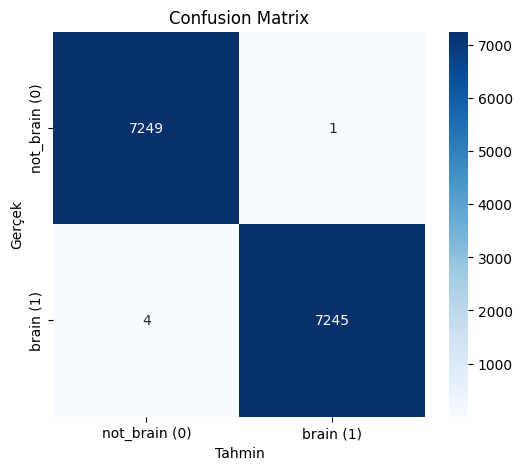

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['not_brain (0)', 'brain (1)'],
    yticklabels=['not_brain (0)', 'brain (1)']
)

plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=['not_brain (0)', 'brain (1)']
    )
)


               precision    recall  f1-score   support

not_brain (0)       1.00      1.00      1.00      7250
    brain (1)       1.00      1.00      1.00      7249

     accuracy                           1.00     14499
    macro avg       1.00      1.00      1.00     14499
 weighted avg       1.00      1.00      1.00     14499



In [ ]:
MODEL_PATH = "/content/brain_mri_model_1.keras"
model.save(MODEL_PATH)
print("Model kaydedildi:", MODEL_PATH)


Model kaydedildi: /content/brain_mri_model_1.keras


In [ ]:
from google.colab import files
files.download(MODEL_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving Gemini_Generated_Image_u0y2cdu0y2cdu0y2.png to Gemini_Generated_Image_u0y2cdu0y2cdu0y2.png
Saving Gemini_Generated_Image_hws29ehws29ehws2.png to Gemini_Generated_Image_hws29ehws29ehws2.png
Seçilen dosya: Gemini_Generated_Image_u0y2cdu0y2cdu0y2.png


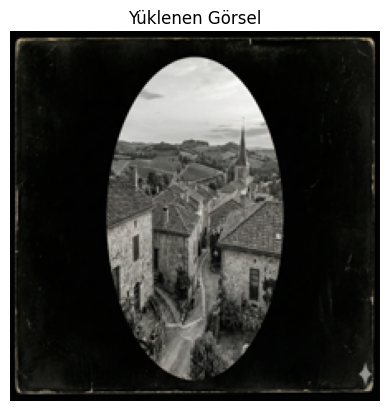

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
Olasılık (brain): 0.0012
❌ SONUÇ: NOT BRAIN (0)
Seçilen dosya: Gemini_Generated_Image_hws29ehws29ehws2.png


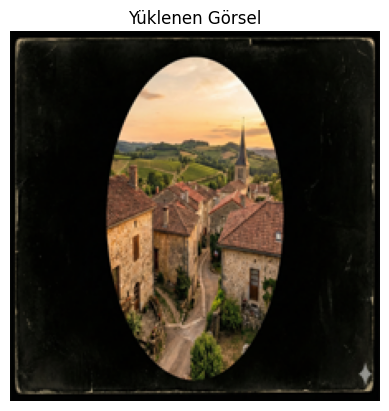

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Olasılık (brain): 0.0000
❌ SONUÇ: NOT BRAIN (0)


In [ ]:
from google.colab import files
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# MODEL YÜKLE (dosya adın buysa)
model = tf.keras.models.load_model("/content/brain_mri_model_1.keras")

IMG_SIZE = (224, 224)

# 📂 Dosya seç
uploaded = files.upload()

for filename in uploaded.keys():
    print("Seçilen dosya:", filename)

    # Görseli yükle
    img = Image.open(filename).convert("RGB")
    img_resized = img.resize(IMG_SIZE)

    # Göster
    plt.imshow(img_resized)
    plt.axis("off")
    plt.title("Yüklenen Görsel")
    plt.show()

    # Normalize + batch
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Tahmin
    prob = model.predict(img_array)[0][0]

    print(f"Olasılık (brain): {prob:.4f}")

    if prob > 0.5:
        print("🧠 SONUÇ: BRAIN MRI (1)")
    else:
        print("❌ SONUÇ: NOT BRAIN (0)")
